In [14]:
import numpy as np
import os
import astropy.units as u
import pandas as pd
from datetime import datetime, timedelta
from astropy.time import Time
import re
from sunpy.coordinates import sun
import helio_coords as hcoords

import matplotlib.animation as animation
import matplotlib as mpl
mpl.rcParams['animation.ffmpeg_path'] = '/opt/miniconda3/envs/huxt/bin/ffmpeg'

import joblib
import onnxruntime as ort

import huxt as H
import huxt_inputs as Hin
import huxt_analysis as HA
import huxt_insitu as His

In [15]:
# Function to convert a date string to a datetime object
def convert_to_datetime(date_str):
    # List of possible date formats
    date_formats = [
        '%Y-%m-%d %H:%M:%S',
        '%Y/%m/%d %H%M',
        '%Y/%m/%d %H%M(%S)',
        '%Y/%m/%d %H%M(S)',
        '%Y/%m/%d %H:%M',
        '%Y/%m/%d %H:%M:%S',
        '%Y/%m/%d %H:%M(S)',
        '%d/%m/%Y %H:%M'
    ]
    for date_format in date_formats:
        try:
            return datetime.strptime(date_str, date_format)
        except ValueError:
            continue
    # If no format matches, return None
    return None
    
# Function to convert Time_Error from string to timedelta
def convert_to_timedelta(time_str):
    try:
        return pd.to_timedelta(time_str)
    except ValueError:
        return None

In [16]:
# Read in Met Office Cone CME files
project_dirs = H._setup_dirs_()
crpath = os.path.join(project_dirs['input'],'(I)CMEs.csv')

# Load the CSV file into a DataFrame
crlist = pd.read_csv(crpath, nrows=1)

# Convert date columns to datetime objects using datetime library
date_columns = ['Time_21.5', 'Disturbance_Time']
for column in date_columns:
    crlist[column] = crlist[column].apply(lambda x: convert_to_datetime(x) if isinstance(x, str) else None)

# compute 21.5-215 transit time
crlist['tt_21'] = np.nan 
for irow in range(0, len(crlist)):
    crlist.loc[irow,'tt_21'] = crlist.loc[irow,'Disturbance_Time'] - crlist.loc[irow,'Time_21.5']
# Convert  from timedelta to days
crlist['tt_21'] = crlist['tt_21'].apply(lambda x: x.days + x.seconds / 86400 if isinstance(x, timedelta) else None)

# Add a new column with carrington rotation number of CME time
crlist['cr_num'] = crlist['Time_21.5'].apply(lambda dt: Hin.datetime2huxtinputs(dt)[0])
crlist['cr_lon_init'] = crlist['Time_21.5'].apply(lambda dt: Hin.datetime2huxtinputs(dt)[1])
crlist['earth_lat'] = crlist['Time_21.5'].apply(lambda dt: get_earth_lat(dt))

/var/folders/ny/0p_7l18s37704rxbjw3bptmw0000gn/T/ipykernel_27627/459609119.py:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2 days 05:50:00' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  crlist.loc[irow,'tt_21'] = crlist.loc[irow,'Disturbance_Time'] - crlist.loc[irow,'Time_21.5']


Files Downloaded: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00,  6.98file/s]


removing ICME #549
removing ICME #550
removing ICME #551


/Users/dven/repos/CME_pulse_duration/huxt/huxt_insitu.py:420: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  omni_input['lon_carr'] = 2 * np.pi * (1 - (cr_frac - cr))


Single longitude simulated. Extracting time series at Observer r


Files Downloaded: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00,  7.32file/s]


(<Figure size 1400x400 with 1 Axes>,
 array([<Axes: xlabel='Date', ylabel='Solar Wind Speed (km/s)'>],
       dtype=object))

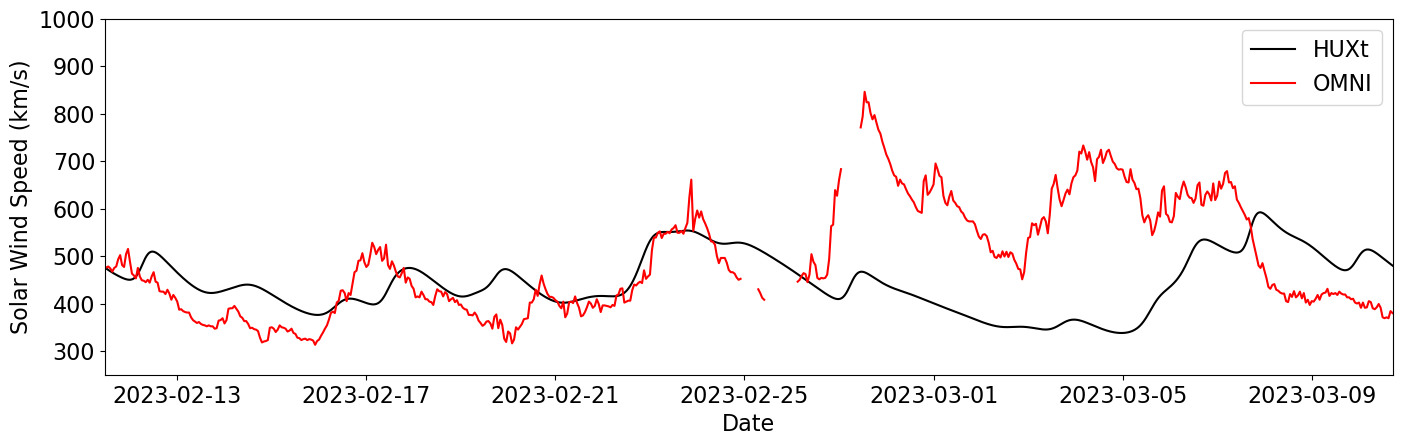

In [17]:
onecme = crlist.iloc[0,:]
start_time = onecme['Time_21.5']

dl_starttime = start_time - timedelta(days=13.6)
dl_endtime = start_time + timedelta(days=13.6)

omni = Hin.get_omni(dl_starttime, dl_endtime)

omni_noicmes = His.removeICMEs(omni, 
                icme_list = 'CaneRichardson',
                pre_icme_buffer = 0.2, #days
                post_icme_buffer = 1, #days
                interp_gaps = True )

model = His.omniHUXt_forecast(start_time, simtime = 27.27*u.day, 
                            rmin = rmin, rmax = rmax, 
                            dt_scale = dt_scale,
                            omni_input = omni_noicmes, buffertime = 0*u.day)

model.solve([])
HA.plot_earth_timeseries(model)

Files Downloaded: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00,  7.31file/s]


removing ICME #549
removing ICME #550
removing ICME #551


/Users/dven/repos/CME_pulse_duration/huxt/huxt_insitu.py:420: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  omni_input['lon_carr'] = 2 * np.pi * (1 - (cr_frac - cr))


Single longitude simulated. Extracting time series at Observer r


Files Downloaded: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00,  7.36file/s]


(<Figure size 1400x400 with 1 Axes>,
 array([<Axes: xlabel='Date', ylabel='Solar Wind Speed (km/s)'>],
       dtype=object))

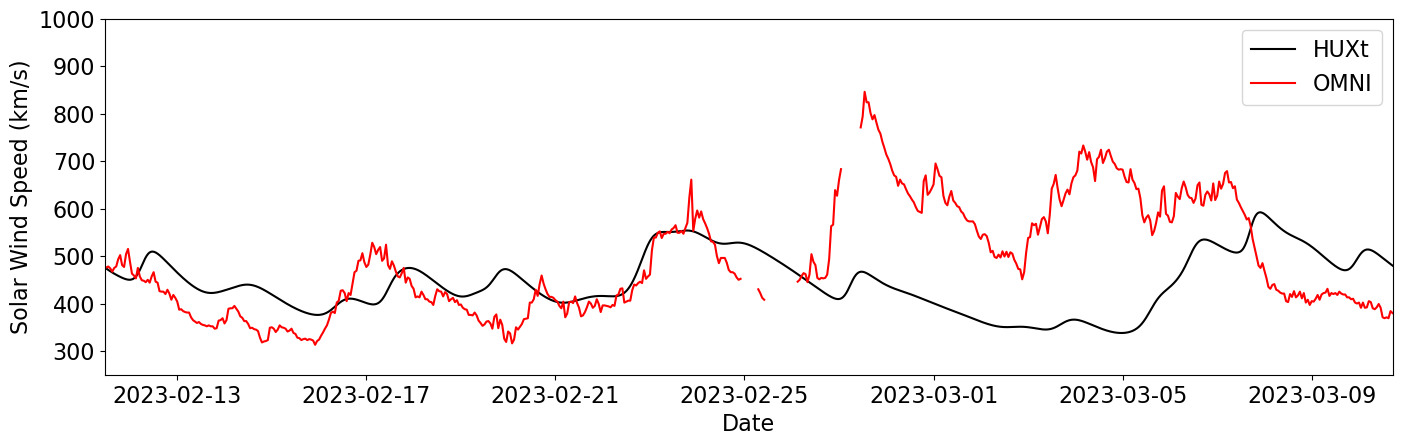

In [20]:
onecme = crlist.iloc[0,:]
start_time = onecme['Time_21.5']

dl_starttime = start_time - timedelta(days=27.27)
dl_endtime = start_time

omni = Hin.get_omni(dl_starttime, dl_endtime)

omni_noicmes = His.removeICMEs(omni, 
                icme_list = 'CaneRichardson',
                pre_icme_buffer = 0.2, #days
                post_icme_buffer = 1, #days
                interp_gaps = True )

model = His.omniHUXt_forecast(start_time, simtime = 27.27*u.day, 
                            rmin = rmin, rmax = rmax, 
                            dt_scale = dt_scale,
                            omni_input = omni_noicmes, buffertime = 0*u.day)

cme = H.ConeCME(t_launch=0.0 * u.day,
                longitude=onecme['lon'] * u.deg,
                latitude=onecme['lat'] * u.deg,
                initial_height=rmin,
                width=2.0 * onecme['Ang_rad'] * u.deg,
                v=onecme['CME_V'] * (u.km / u.s),
                thickness=0.0 * u.solRad,
                cme_expansion=False,
                cme_fixed_duration=True,
                fixed_duration=11.0 * 60 * 60 * u.s)

model.solve([cme])
cme_out = model.cmes[0]

#HA.animate(model, tag='', outputfilepath="/Users/dven/repos/CME_pulse_duration/huxt/figures/analysis/CR2267.mp4")
HA.plot_earth_timeseries(model, plot_omni=True)